# colab notebook

https://colab.research.google.com/drive/1NGM2so-vXNspvR1Qml9y6tXMrrAca0kO?usp=sharing

# imports & installs

In [1]:
!nvidia-smi
!pip install --quiet cudf-cu12 cuml-cu12 dask-cuda --extra-index-url=https://pypi.nvidia.com

Wed Nov 26 18:24:52 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   33C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import cudf
import cuml
import cupy as cp
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from cuml.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

# load data

In [3]:
df_train = cudf.read_csv("/content/train_clusters.csv")

df_train = df_train.sort_values("start_interval").reset_index(drop=True)

display(df_train.head(10))
print("columns: ", df_train.columns)
print("shape: ", df_train.shape)

,start_interval,route_1_0,route_1_1,route_2_0,route_2_1,route_3_0,route_3_1,route_4_0,route_4_1,route_5_0,...,motorcycle,taxi,brooklyn,east_60,fdr,nj,queens,west_60,west_side_hwy,cluster
0,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,1082
1,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,0,0,1,0,0,0,0,0,1082
2,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,1082
3,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,1082
4,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,1082
5,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,1,0,0,-1
6,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,1,-1
7,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,1,0,1082
8,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,1,1082
9,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,1,0,1082


columns:  Index(['start_interval', 'route_1_0', 'route_1_1', 'route_2_0', 'route_2_1',
       'route_3_0', 'route_3_1', 'route_4_0', 'route_4_1', 'route_5_0',
       'route_5_1', 'route_6_0', 'route_6_1', 'route_6X_0', 'route_6X_1',
       'route_7_0', 'route_7_1', 'route_7X_0', 'route_7X_1', 'route_A_0',
       'route_A_1', 'route_B_0', 'route_B_1', 'route_C_0', 'route_C_1',
       'route_D_0', 'route_D_1', 'route_E_0', 'route_E_1', 'route_F_0',
       'route_F_1', 'route_FS_0', 'route_FS_1', 'route_FX_0', 'route_FX_1',
       'route_G_0', 'route_G_1', 'route_GS_0', 'route_GS_1', 'route_H_0',
       'route_H_1', 'route_J_0', 'route_J_1', 'route_L_0', 'route_L_1',
       'route_M_0', 'route_M_1', 'route_N_0', 'route_N_1', 'route_Q_0',
       'route_Q_1', 'route_R_0', 'route_R_1', 'route_SI_0', 'route_SI_1',
       'route_SS_0', 'route_SS_1', 'route_W_0', 'route_W_1', 'route_Z_0',
       'route_Z_1', 'total_trips', 'avg_delay', 'entries',
       'excluded_roadway_entries', 'overnight', 

In [4]:
df_val = cudf.read_csv("/content/val_clusters.csv")

df_val = df_val.sort_values("start_interval").reset_index(drop=True)

display(df_val.head(10))
print("columns: ", df_val.columns)
print("shape: ", df_val.shape)

,start_interval,route_1_0,route_1_1,route_2_0,route_2_1,route_3_0,route_3_1,route_4_0,route_4_1,route_5_0,...,motorcycle,taxi,brooklyn,east_60,fdr,nj,queens,west_60,west_side_hwy,cluster
0,2025-09-15 12:00:00,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,1,0,0,0,-1
1,2025-09-15 12:00:00,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,1,-1
2,2025-09-15 12:00:00,1,1,1,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,-1
3,2025-09-15 12:00:00,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,1,0,-1
4,2025-09-15 12:00:00,1,1,1,1,1,1,1,1,1,...,0,0,0,1,0,0,0,0,0,-1
5,2025-09-15 12:00:00,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,1,0,0,-1
6,2025-09-15 12:00:00,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,1,0,-1
7,2025-09-15 12:00:00,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,-1
8,2025-09-15 12:00:00,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,1,0,-1
9,2025-09-15 12:00:00,1,1,1,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,-1


columns:  Index(['start_interval', 'route_1_0', 'route_1_1', 'route_2_0', 'route_2_1',
       'route_3_0', 'route_3_1', 'route_4_0', 'route_4_1', 'route_5_0',
       'route_5_1', 'route_6_0', 'route_6_1', 'route_6X_0', 'route_6X_1',
       'route_7_0', 'route_7_1', 'route_7X_0', 'route_7X_1', 'route_A_0',
       'route_A_1', 'route_B_0', 'route_B_1', 'route_C_0', 'route_C_1',
       'route_D_0', 'route_D_1', 'route_E_0', 'route_E_1', 'route_F_0',
       'route_F_1', 'route_FS_0', 'route_FS_1', 'route_FX_0', 'route_FX_1',
       'route_G_0', 'route_G_1', 'route_GS_0', 'route_GS_1', 'route_H_0',
       'route_H_1', 'route_J_0', 'route_J_1', 'route_L_0', 'route_L_1',
       'route_M_0', 'route_M_1', 'route_N_0', 'route_N_1', 'route_Q_0',
       'route_Q_1', 'route_R_0', 'route_R_1', 'route_SI_0', 'route_SI_1',
       'route_SS_0', 'route_SS_1', 'route_W_0', 'route_W_1', 'route_Z_0',
       'route_Z_1', 'total_trips', 'avg_delay', 'entries',
       'excluded_roadway_entries', 'overnight', 

In [5]:
df_test = cudf.read_csv("/content/test_clusters.csv")

df_test = df_test.sort_values("start_interval").reset_index(drop=True)

display(df_test.head(10))
print("columns: ", df_test.columns)
print("shape: ", df_test.shape)

,start_interval,route_1_0,route_1_1,route_2_0,route_2_1,route_3_0,route_3_1,route_4_0,route_4_1,route_5_0,...,motorcycle,taxi,brooklyn,east_60,fdr,nj,queens,west_60,west_side_hwy,cluster
0,2025-09-25 06:00:00,1,1,1,1,0,1,1,1,1,...,0,1,0,0,0,0,0,0,1,-1
1,2025-09-25 06:00:00,1,1,1,1,0,1,1,1,1,...,0,0,0,0,0,0,1,0,0,-1
2,2025-09-25 06:00:00,1,1,1,1,0,1,1,1,1,...,0,0,1,0,0,0,0,0,0,-1
3,2025-09-25 06:00:00,1,1,1,1,0,1,1,1,1,...,0,0,0,0,0,0,0,1,0,-1
4,2025-09-25 06:00:00,1,1,1,1,0,1,1,1,1,...,0,0,0,1,0,0,0,0,0,-1
5,2025-09-25 06:00:00,1,1,1,1,0,1,1,1,1,...,0,0,0,0,0,0,0,1,0,-1
6,2025-09-25 06:00:00,1,1,1,1,0,1,1,1,1,...,0,0,0,0,0,1,0,0,0,-1
7,2025-09-25 06:00:00,1,1,1,1,0,1,1,1,1,...,0,1,0,0,0,0,0,1,0,-1
8,2025-09-25 06:00:00,1,1,1,1,0,1,1,1,1,...,0,1,0,0,1,0,0,0,0,-1
9,2025-09-25 06:00:00,1,1,1,1,0,1,1,1,1,...,0,1,1,0,0,0,0,0,0,-1


columns:  Index(['start_interval', 'route_1_0', 'route_1_1', 'route_2_0', 'route_2_1',
       'route_3_0', 'route_3_1', 'route_4_0', 'route_4_1', 'route_5_0',
       'route_5_1', 'route_6_0', 'route_6_1', 'route_6X_0', 'route_6X_1',
       'route_7_0', 'route_7_1', 'route_7X_0', 'route_7X_1', 'route_A_0',
       'route_A_1', 'route_B_0', 'route_B_1', 'route_C_0', 'route_C_1',
       'route_D_0', 'route_D_1', 'route_E_0', 'route_E_1', 'route_F_0',
       'route_F_1', 'route_FS_0', 'route_FS_1', 'route_FX_0', 'route_FX_1',
       'route_G_0', 'route_G_1', 'route_GS_0', 'route_GS_1', 'route_H_0',
       'route_H_1', 'route_J_0', 'route_J_1', 'route_L_0', 'route_L_1',
       'route_M_0', 'route_M_1', 'route_N_0', 'route_N_1', 'route_Q_0',
       'route_Q_1', 'route_R_0', 'route_R_1', 'route_SI_0', 'route_SI_1',
       'route_SS_0', 'route_SS_1', 'route_W_0', 'route_W_1', 'route_Z_0',
       'route_Z_1', 'total_trips', 'avg_delay', 'entries',
       'excluded_roadway_entries', 'overnight', 

# prepare data

In [6]:
vehicle_cols = [
    "car_pickup_van", "single_unit_truck", "multi_unit_truck",
    "bus", "motorcycle", "taxi"
]

detection_cols = [
    "brooklyn", "east_60", "fdr", "nj", "queens", "west_60", "west_side_hwy"
]

def add_labels(df):
    df = df.copy()

    vehicle_matrix = df[vehicle_cols].to_cupy()
    vehicle_idx = cp.argmax(vehicle_matrix, axis=1)
    df["vehicle_class_temp"] = [vehicle_cols[i] for i in vehicle_idx.get()]

    detect_matrix = df[detection_cols].to_cupy()
    detect_idx = cp.argmax(detect_matrix, axis=1)
    df["detection_group_temp"] = [detection_cols[i] for i in detect_idx.get()]

    return df

df_train = add_labels(df_train)
df_val   = add_labels(df_val)
df_test  = add_labels(df_test)

display(df_train.head())
display(df_val.head())
display(df_test.head())

,start_interval,route_1_0,route_1_1,route_2_0,route_2_1,route_3_0,route_3_1,route_4_0,route_4_1,route_5_0,...,brooklyn,east_60,fdr,nj,queens,west_60,west_side_hwy,cluster,vehicle_class_temp,detection_group_temp
0,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,1,0,0,0,0,0,0,1082,bus,brooklyn
1,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,1,0,0,0,0,0,1082,bus,east_60
2,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,0,0,1,0,0,0,1082,bus,nj
3,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,1,0,0,0,0,0,0,1082,single_unit_truck,brooklyn
4,2025-08-01 00:00:00,0,1,0,1,1,1,1,1,1,...,0,0,0,1,0,0,0,1082,single_unit_truck,nj


,start_interval,route_1_0,route_1_1,route_2_0,route_2_1,route_3_0,route_3_1,route_4_0,route_4_1,route_5_0,...,brooklyn,east_60,fdr,nj,queens,west_60,west_side_hwy,cluster,vehicle_class_temp,detection_group_temp
0,2025-09-15 12:00:00,1,1,1,1,1,1,1,1,1,...,0,0,0,1,0,0,0,-1,taxi,nj
1,2025-09-15 12:00:00,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,1,-1,taxi,west_side_hwy
2,2025-09-15 12:00:00,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,-1,single_unit_truck,brooklyn
3,2025-09-15 12:00:00,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,1,0,-1,single_unit_truck,west_60
4,2025-09-15 12:00:00,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,-1,single_unit_truck,east_60


,start_interval,route_1_0,route_1_1,route_2_0,route_2_1,route_3_0,route_3_1,route_4_0,route_4_1,route_5_0,...,brooklyn,east_60,fdr,nj,queens,west_60,west_side_hwy,cluster,vehicle_class_temp,detection_group_temp
0,2025-09-25 06:00:00,1,1,1,1,0,1,1,1,1,...,0,0,0,0,0,0,1,-1,taxi,west_side_hwy
1,2025-09-25 06:00:00,1,1,1,1,0,1,1,1,1,...,0,0,0,0,1,0,0,-1,single_unit_truck,queens
2,2025-09-25 06:00:00,1,1,1,1,0,1,1,1,1,...,1,0,0,0,0,0,0,-1,single_unit_truck,brooklyn
3,2025-09-25 06:00:00,1,1,1,1,0,1,1,1,1,...,0,0,0,0,0,1,0,-1,single_unit_truck,west_60
4,2025-09-25 06:00:00,1,1,1,1,0,1,1,1,1,...,0,1,0,0,0,0,0,-1,single_unit_truck,east_60


In [7]:
def make_interval_summary(df):
    return (
        df.groupby(["start_interval", "vehicle_class_temp", "detection_group_temp"])[
            ["entries", "excluded_roadway_entries"]
        ]
        .mean()
        .reset_index()
        .sort_values(["vehicle_class_temp", "detection_group_temp", "start_interval"])
    )

train_interval = make_interval_summary(df_train)
val_interval   = make_interval_summary(df_val)
test_interval  = make_interval_summary(df_test)

for interval_df in [train_interval, val_interval, test_interval]:
    interval_df["entries_rolling3"] = (
        interval_df.groupby(["vehicle_class_temp", "detection_group_temp"])["entries"]
        .rolling(window=3, min_periods=1).mean()
        .reset_index(level=[0,1], drop=True)
    )
    interval_df["excluded_rolling3"] = (
        interval_df.groupby(["vehicle_class_temp", "detection_group_temp"])["excluded_roadway_entries"]
        .rolling(window=3, min_periods=1).mean()
        .reset_index(level=[0,1], drop=True)
    )

In [8]:
df_train_lag = df_train.merge(
    train_interval[["start_interval", "vehicle_class_temp", "detection_group_temp", "entries_rolling3", "excluded_rolling3"]],
    on=["start_interval", "vehicle_class_temp", "detection_group_temp"],
    how="left"
)

df_val_lag = df_val.merge(
    val_interval[["start_interval", "vehicle_class_temp", "detection_group_temp", "entries_rolling3", "excluded_rolling3"]],
    on=["start_interval", "vehicle_class_temp", "detection_group_temp"],
    how="left"
)

df_test_lag = df_test.merge(
    test_interval[["start_interval", "vehicle_class_temp", "detection_group_temp", "entries_rolling3", "excluded_rolling3"]],
    on=["start_interval", "vehicle_class_temp", "detection_group_temp"],
    how="left"
)

In [9]:
for df_x in [df_train_lag, df_val_lag, df_test_lag]:
    df_x.drop(columns=["vehicle_class_temp", "detection_group_temp"], inplace=True)

for df_x in [df_train_lag, df_val_lag, df_test_lag]:
    df_x["cluster"] = df_x["cluster"].astype("category")

display(df_train_lag.head())
display(df_val_lag.head())
display(df_test_lag.head())

,start_interval,route_1_0,route_1_1,route_2_0,route_2_1,route_3_0,route_3_1,route_4_0,route_4_1,route_5_0,...,brooklyn,east_60,fdr,nj,queens,west_60,west_side_hwy,cluster,entries_rolling3,excluded_rolling3
0,2025-08-03 16:50:00,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,2241,317.666667,33.0
1,2025-08-03 16:50:00,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,-1,414.666667,0.0
2,2025-08-03 16:50:00,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,2241,589.666667,262.0
3,2025-08-03 16:50:00,1,1,1,1,1,1,1,1,1,...,0,0,0,1,0,0,0,-1,673.000000,0.0
4,2025-08-03 16:50:00,1,1,1,1,1,1,1,1,1,...,0,0,0,1,0,0,0,2241,165.000000,0.0


,start_interval,route_1_0,route_1_1,route_2_0,route_2_1,route_3_0,route_3_1,route_4_0,route_4_1,route_5_0,...,brooklyn,east_60,fdr,nj,queens,west_60,west_side_hwy,cluster,entries_rolling3,excluded_rolling3
0,2025-09-17 04:30:00,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,-1,2.333333,0.0
1,2025-09-17 04:30:00,1,1,1,1,1,1,1,1,1,...,0,0,0,1,0,0,0,-1,3.666667,0.0
2,2025-09-17 04:30:00,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,1,0,-1,0.666667,0.0
3,2025-09-17 04:30:00,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,-1,2.000000,0.0
4,2025-09-17 04:30:00,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,-1,1.333333,0.0


,start_interval,route_1_0,route_1_1,route_2_0,route_2_1,route_3_0,route_3_1,route_4_0,route_4_1,route_5_0,...,brooklyn,east_60,fdr,nj,queens,west_60,west_side_hwy,cluster,entries_rolling3,excluded_rolling3
0,2025-09-26 11:40:00,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,-1,260.000000,0.000000
1,2025-09-26 11:40:00,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,-1,292.333333,37.333333
2,2025-09-26 11:40:00,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,-1,306.000000,0.000000
3,2025-09-26 11:40:00,1,1,1,1,1,1,1,1,1,...,0,0,1,0,0,0,0,-1,332.666667,199.666667
4,2025-09-26 11:40:00,1,1,1,1,1,1,1,1,1,...,0,0,0,1,0,0,0,-1,508.333333,0.000000


In [10]:
target_cols = ["entries", "excluded_roadway_entries"]

drop_cols = target_cols + ["start_interval"]
X_train = df_train_lag.drop(columns=drop_cols)
y_train = df_train_lag[target_cols]

X_val = df_val_lag.drop(columns=drop_cols)
y_val = df_val_lag[target_cols]

X_test = df_test_lag.drop(columns=drop_cols)
y_test = df_test_lag[target_cols]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (275184, 87), Val: (58968, 87), Test: (58968, 87)


In [11]:
print(X_train.dtypes)

route_1_0               int64
route_1_1               int64
route_2_0               int64
route_2_1               int64
route_3_0               int64
                       ...   
west_60                 int64
west_side_hwy           int64
cluster              category
entries_rolling3      float64
excluded_rolling3     float64
Length: 87, dtype: object


# fit model

In [12]:
xgb=MultiOutputRegressor(XGBRegressor(
        random_state=42,
        enable_categorical=True,
        objective='reg:squarederror',
        tree_method='hist',
        n_jobs=-1
))

param_distributions = {
    'estimator__n_estimators': [200, 400, 600], # number of trees
    'estimator__max_depth': [3, 4, 6, 8], # tree depth (controls complexity; smaller = more regularization)
    'estimator__learning_rate': [0.01, 0.05, 0.1, 0.2], # learning rate (shrinkage step size)
    'estimator__subsample': [0.6, 0.8, 1.0], # row subsampling for each tree (like RF's bootstrap but per-boosting step)
    'estimator__colsample_bytree': [0.6, 0.8, 1.0], # column subsampling for each tree (similar idea to RF's max_features)
    'estimator__reg_lambda': [0.0, 1.0, 10.0], # L2 regularization on weights (ridge-like)
}

tscv = TimeSeriesSplit(n_splits=3)

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_distributions,
    n_iter=10,
    scoring='r2',
    cv=tscv,
    random_state=42,
    verbose=2
)

search.fit(X_train.to_pandas(), y_train.to_pandas())

print("\nBest parameters:")
print(search.best_params_)
print(f"Best CV R^2: {search.best_score_:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END estimator__colsample_bytree=1.0, estimator__learning_rate=0.1, estimator__max_depth=4, estimator__n_estimators=600, estimator__reg_lambda=0.0, estimator__subsample=0.8; total time=   7.8s
[CV] END estimator__colsample_bytree=1.0, estimator__learning_rate=0.1, estimator__max_depth=4, estimator__n_estimators=600, estimator__reg_lambda=0.0, estimator__subsample=0.8; total time=  11.3s
[CV] END estimator__colsample_bytree=1.0, estimator__learning_rate=0.1, estimator__max_depth=4, estimator__n_estimators=600, estimator__reg_lambda=0.0, estimator__subsample=0.8; total time=  14.8s
[CV] END estimator__colsample_bytree=0.8, estimator__learning_rate=0.2, estimator__max_depth=8, estimator__n_estimators=600, estimator__reg_lambda=1.0, estimator__subsample=1.0; total time=  19.3s
[CV] END estimator__colsample_bytree=0.8, estimator__learning_rate=0.2, estimator__max_depth=8, estimator__n_estimators=600, estimator__reg_lambda=1.0,

# evaluate model

In [13]:
best_xgb = search.best_estimator_

def evaluate(model, X, y, name, target_cols):
    X_cpu = X.to_pandas()
    y_cpu = y.to_pandas()
    preds = model.predict(X_cpu)

    preds_df = pd.DataFrame(preds, columns=target_cols, index=y_cpu.index)

    metrics = {"Set": name}

    for col in target_cols:
        r2 = r2_score(y_cpu[col], preds_df[col])
        mse = mean_squared_error(y_cpu[col], preds_df[col])
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_cpu[col], preds_df[col])

        metrics[f"{col} R^2"] = r2
        metrics[f"{col} RMSE"] = rmse
        metrics[f"{col} MAE"] = mae

    metrics["Mean R^2"] = np.mean([metrics[f"{c} R^2"] for c in target_cols])
    metrics["Mean RMSE"] = np.mean([metrics[f"{c} RMSE"] for c in target_cols])
    metrics["Mean MAE"] = np.mean([metrics[f"{c} MAE"] for c in target_cols])

    return metrics

target_cols = ['entries', 'excluded_roadway_entries']

results = [
    evaluate(best_xgb, X_train, y_train, "Train", target_cols),
    evaluate(best_xgb, X_val, y_val, "Validation", target_cols),
    evaluate(best_xgb, X_test, y_test, "Test", target_cols),
]

results_df = pd.DataFrame(results)
print("\nSummary:")
display(results_df)


Summary:


,Set,entries R^2,entries RMSE,entries MAE,excluded_roadway_entries R^2,excluded_roadway_entries RMSE,excluded_roadway_entries MAE,Mean R^2,Mean RMSE,Mean MAE
0,Train,0.995881,9.205504,4.530966,0.996941,2.436915,0.689039,0.996411,5.821209,2.610002
1,Validation,0.993186,11.881477,5.664854,0.989568,4.311661,1.069612,0.991377,8.096569,3.367233
2,Test,0.993473,11.930990,5.688974,0.990084,4.240010,1.068696,0.991778,8.085500,3.378835


In [14]:
n_train, p = X_train.shape
n_val = len(X_val)
n_test = len(X_test)

def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * ((n - 1) / (n - p - 1))

for col in target_cols:
  results_df[f"{col} Adjusted R^2"] = [
      adjusted_r2(results_df.loc[0, f"{col} R^2"], n_train, p),
      adjusted_r2(results_df.loc[1, f"{col} R^2"], n_val, p),
      adjusted_r2(results_df.loc[2, f"{col} R^2"], n_test, p),
  ]

results_df["Mean Adjusted R^2"] = results_df[
    [f"{c} Adjusted R^2" for c in target_cols]
].mean(axis=1)

display(results_df)

,Set,entries R^2,entries RMSE,entries MAE,excluded_roadway_entries R^2,excluded_roadway_entries RMSE,excluded_roadway_entries MAE,Mean R^2,Mean RMSE,Mean MAE,entries Adjusted R^2,excluded_roadway_entries Adjusted R^2,Mean Adjusted R^2
0,Train,0.995881,9.205504,4.530966,0.996941,2.436915,0.689039,0.996411,5.821209,2.610002,0.995880,0.996940,0.996410
1,Validation,0.993186,11.881477,5.664854,0.989568,4.311661,1.069612,0.991377,8.096569,3.367233,0.993176,0.989553,0.991364
2,Test,0.993473,11.930990,5.688974,0.990084,4.240010,1.068696,0.991778,8.085500,3.378835,0.993463,0.990070,0.991766


In [15]:
y_train_cpu = y_train.to_pandas()
y_val_cpu = y_val.to_pandas()
y_test_cpu = y_test.to_pandas()

def summarize_relative_errors(split_name, y_cpu, row, target_cols):
    print(f"\n{split_name} set:")
    for col in target_cols:
        mean_y = y_cpu[col].mean()
        std_y = y_cpu[col].std()
        rmse = row[f"{col} RMSE"]
        mae = row[f"{col} MAE"]

        print(f"\nTarget: {col}")
        print(f"- Mean of target: {mean_y:.2f}")
        print(f"- Std of target:  {std_y:.2f}")
        print(f"- RMSE as % of mean: {rmse / mean_y * 100:.2f}%")
        print(f"- MAE as % of mean:  {mae / mean_y * 100:.2f}%")
        print(f"- RMSE as % of std:  {rmse / std_y * 100:.2f}%")
        print(f"- MAE as % of std:  {mae / std_y * 100:.2f}%")

for _, row in results_df.iterrows():
    split = row["Set"]
    if split == "Train":
        summarize_relative_errors(split, y_train_cpu, row, target_cols)
    elif split == "Validation":
        summarize_relative_errors(split, y_val_cpu, row, target_cols)
    elif split == "Test":
        summarize_relative_errors(split, y_test_cpu, row, target_cols)


Train set:

Target: entries
- Mean of target: 80.93
- Std of target:  143.43
- RMSE as % of mean: 11.37%
- MAE as % of mean:  5.60%
- RMSE as % of std:  6.42%
- MAE as % of std:  3.16%

Target: excluded_roadway_entries
- Mean of target: 11.29
- Std of target:  44.06
- RMSE as % of mean: 21.58%
- MAE as % of mean:  6.10%
- RMSE as % of std:  5.53%
- MAE as % of std:  1.56%

Validation set:

Target: entries
- Mean of target: 82.88
- Std of target:  143.93
- RMSE as % of mean: 14.34%
- MAE as % of mean:  6.83%
- RMSE as % of std:  8.25%
- MAE as % of std:  3.94%

Target: excluded_roadway_entries
- Mean of target: 10.86
- Std of target:  42.22
- RMSE as % of mean: 39.69%
- MAE as % of mean:  9.85%
- RMSE as % of std:  10.21%
- MAE as % of std:  2.53%

Test set:

Target: entries
- Mean of target: 85.78
- Std of target:  147.68
- RMSE as % of mean: 13.91%
- MAE as % of mean:  6.63%
- RMSE as % of std:  8.08%
- MAE as % of std:  3.85%

Target: excluded_roadway_entries
- Mean of target: 11.04

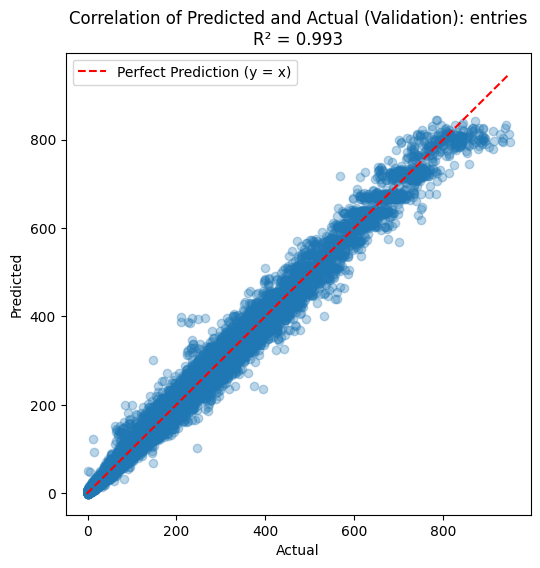

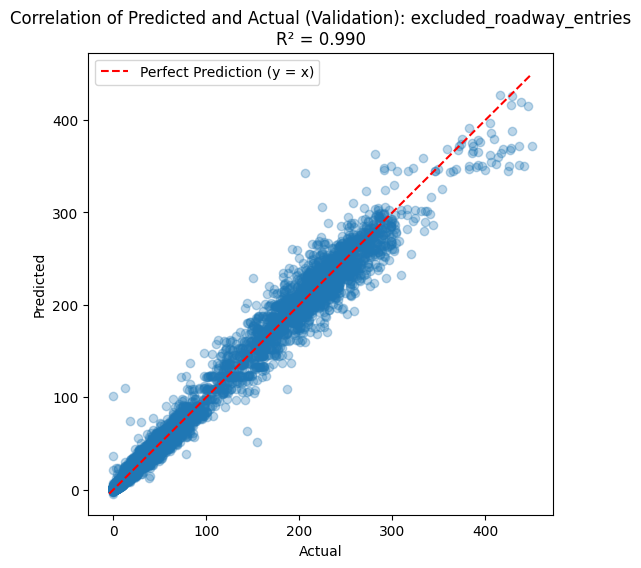

In [16]:
y_true_val = y_val_cpu
y_pred_val = pd.DataFrame(best_xgb.predict(X_val.to_pandas()), columns=target_cols, index=y_val_cpu.index)

for col in target_cols:
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true_val[col], y_pred_val[col], alpha=0.3)

    min_val = min(y_true_val[col].min(), y_pred_val[col].min())
    max_val = max(y_true_val[col].max(), y_pred_val[col].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Perfect Prediction (y = x)")

    r2_col = f"{col} R^2"
    r2_val = results_df.loc[results_df["Set"] == "Validation", r2_col].values[0]

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Correlation of Predicted and Actual (Validation): {col}\nR² = {r2_val:.3f}")

    plt.legend()
    plt.show()

# save results

In [17]:
feature_names = list(X_train.to_pandas().columns)
all_importances = {}

for i, est in enumerate(best_xgb.estimators_):
    importances = est.feature_importances_
    all_importances[target_cols[i]] = importances

feat_imp_df = pd.DataFrame(all_importances, index=feature_names)
display(feat_imp_df)

,entries,excluded_roadway_entries
route_1_0,0.000028,0.001257
route_1_1,0.000183,0.000265
route_2_0,0.000177,0.000715
route_2_1,0.000239,0.000072
route_3_0,0.000099,0.000686
...,...,...
west_60,0.000139,0.000000
west_side_hwy,0.000101,0.000427
cluster,0.001316,0.004109
entries_rolling3,0.966502,0.000500


In [18]:
feat_imp_df.to_csv('/content/xgb_feature_importances.csv', index=True)

In [ ]:
y_val_cpu = y_val.to_pandas()
y_test_cpu = y_test.to_pandas()

y_pred_val = pd.DataFrame(
    best_xgb.predict(X_val.to_pandas()),
    columns=[f"predicted_{c}" for c in target_cols],
    index=y_val_cpu.index
)

y_pred_test = pd.DataFrame(
    best_xgb.predict(X_test.to_pandas()),
    columns=[f"predicted_{c}" for c in target_cols],
    index=y_test_cpu.index
)

start_val = df_val_lag.to_pandas().loc[y_val_cpu.index, "start_interval"]
start_test = df_test_lag.to_pandas().loc[y_test_cpu.index, "start_interval"]

val_out = pd.DataFrame({
    "start_interval": start_val,
    "entries": y_val_cpu["entries"],
    "excluded_roadway_entries": y_val_cpu["excluded_roadway_entries"],
    "predicted_entries": y_pred_val["predicted_entries"],
    "predicted_excluded_roadway_entries": y_pred_val["predicted_excluded_roadway_entries"],
})

test_out = pd.DataFrame({
    "start_interval": start_test,
    "entries": y_test_cpu["entries"],
    "excluded_roadway_entries": y_test_cpu["excluded_roadway_entries"],
    "predicted_entries": y_pred_test["predicted_entries"],
    "predicted_excluded_roadway_entries": y_pred_test["predicted_excluded_roadway_entries"],
})

val_out["entries_residual"] = val_out["entries"] - val_out["predicted_entries"]
val_out["excluded_roadway_entries_residual"] = val_out["excluded_roadway_entries"] - val_out["predicted_excluded_roadway_entries"]

test_out["entries_residual"] = test_out["entries"] - test_out["predicted_entries"]
test_out["excluded_roadway_entries_residual"] = test_out["excluded_roadway_entries"] - test_out["predicted_excluded_roadway_entries"]

print("\nValidation results:")
display(val_out.head())

print("\nTest results:")
display(test_out.head())


Validation results:


,start_interval,entries,excluded_roadway_entries,predicted_entries,predicted_excluded_roadway_entries,entries_residual,excluded_roadway_entries_residual
0,2025-09-15 19:50:00,205,0,207.387817,-0.160143,-2.387817,0.160143
1,2025-09-15 19:50:00,216,0,213.971619,0.047544,2.028381,-0.047544
2,2025-09-15 19:50:00,258,0,247.159271,-0.075408,10.840729,0.075408
3,2025-09-15 19:50:00,269,210,264.963898,213.123688,4.036102,-3.123688
4,2025-09-15 19:50:00,329,0,319.018494,-0.015529,9.981506,0.015529



Test results:


,start_interval,entries,excluded_roadway_entries,predicted_entries,predicted_excluded_roadway_entries,entries_residual,excluded_roadway_entries_residual
0,2025-09-26 00:20:00,9,0,7.677720,-0.015234,1.322280,0.015234
1,2025-09-26 00:20:00,75,91,72.974426,98.665543,2.025574,-7.665543
2,2025-09-26 00:20:00,14,0,15.621967,-0.016490,-1.621967,0.016490
3,2025-09-26 00:20:00,81,1,90.493942,3.343476,-9.493942,-2.343476
4,2025-09-26 00:20:00,152,0,143.637146,-0.047299,8.362854,0.047299


In [ ]:
def check_nans(df_name, df, target_cols):
    print(f"\n{df_name} set:")
    print(f"- Rows total: {len(df)}")

    for col in target_cols:
        pred_col = f"predicted_{col}"
        resid_col = f"{col}_residual"

        n_pred = df[pred_col].isna().sum()
        n_resid = df[resid_col].isna().sum()

        print(f"\nTarget: {col}")
        print(f"- NaNs in {pred_col}: {n_pred}")
        print(f"- NaNs in {resid_col}: {n_resid}")

check_nans("Validation", val_out, target_cols)
check_nans("Test", test_out, target_cols)


Validation set:
- Rows total: 58968

Target: entries
- NaNs in predicted_entries: 0
- NaNs in entries_residual: 0

Target: excluded_roadway_entries
- NaNs in predicted_excluded_roadway_entries: 0
- NaNs in excluded_roadway_entries_residual: 0

Test set:
- Rows total: 58968

Target: entries
- NaNs in predicted_entries: 0
- NaNs in entries_residual: 0

Target: excluded_roadway_entries
- NaNs in predicted_excluded_roadway_entries: 0
- NaNs in excluded_roadway_entries_residual: 0


In [ ]:
val_out.to_csv("/content/xgb_val_preds_final.csv", index=False)
test_out.to_csv("/content/xgb_test_preds_final.csv", index=False)